In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
social_emotions=pd.read_csv(r"D:\桌面\python 数据值\Social_Media_Sentiment_Analysis_AI_Trends_2026.csv",sep=',')
social_emotions.head(10)

,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,day_of_week,is_trending_topic,topic_category,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url
0,YouTube,YO_100000,user_2679,rxckafna,True,375410,Germany,I don’t agree with this at all.,ur,"#news,#update",...,Wed,True,Technology,Positive,0.82,Sad,0.10,False,True,https://www.youtube.com
1,Reddit,RE_100001,user_3045,zjovqwps,True,346702,UK,Worst decision ever made.,fr,"#trending,#ai",...,Tue,False,Sports,Neutral,-0.02,Angry,0.67,True,True,https://www.reddit.com
2,YouTube,YO_100002,user_4598,rvufaigf,False,111487,Germany,This trend is getting out of hand.,de,"#news,#update",...,Fri,False,Finance,Positive,0.62,Neutral,0.43,False,False,https://www.youtube.com
3,Twitter,TW_100003,user_3504,qukbjznz,True,356674,Germany,Pretty neutral about the update.,en,"#trending,#ai",...,Thu,True,Finance,Neutral,0.14,Sad,0.97,True,True,https://www.twitter.com
4,YouTube,YO_100004,user_3646,ounaiayw,False,125551,USA,"Loved the explanation, very helpful.",es,"#trending,#ai",...,Sun,True,Technology,Neutral,-0.05,Fear,0.95,True,False,https://www.youtube.com
5,YouTube,YO_100005,user_4295,skrjxlgb,True,308453,Pakistan,I’m confused about the announcement.,es,"#trending,#ai",...,Mon,True,Sports,Negative,-0.35,Fear,0.21,True,False,https://www.youtube.com
6,Twitter,TW_100006,user_7939,kwbqqbsu,True,130377,UK,People need to talk about this more.,es,"#trending,#ai",...,Thu,True,Politics,Negative,-0.93,Neutral,0.84,True,True,https://www.twitter.com
7,Twitter,TW_100007,user_3697,jzgulkyz,False,81168,UK,"Not bad, but could be better.",fr,"#news,#update",...,Thu,True,Politics,Negative,-0.39,Neutral,0.08,True,True,https://www.twitter.com
8,YouTube,YO_100008,user_5033,pbcroigr,False,125150,Canada,I don’t agree with this at all.,de,"#news,#update",...,Fri,True,Politics,Neutral,0.18,Neutral,0.21,False,True,https://www.youtube.com
9,Reddit,RE_100009,user_5956,pzravhry,True,138666,USA,I don’t agree with this at all.,en,"#trending,#ai",...,Sat,False,Health,Positive,0.56,Fear,0.25,True,True,https://www.reddit.com


In [3]:
social_emotions=social_emotions.rename(columns={"platform":"发布平台","post_id":"帖子ID","user_id":"用户ID","username":"用户名","user_verified":"是否认证",
"user_followers_count":"粉丝数","user_location":"用户位置","post_text":"帖子正文","language":"语言","hashtags":"话题标签",
"mentions":"@提及用户","post_length":"帖子长度","like_count":"点赞数","comment_count":"评论数","share_count":"转发数",
"engagement_score":"互动得分","posted_datetime":"发布时间","day_of_week":"星期几","is_trending_topic":"是否热门话题",
"topic_category":"话题类别","sentiment_label":"情感极性","sentiment_score":"情感得分","emotion_label":"具体情绪",
"toxicity_score":"恶意/毒性得分","sarcasm_detected":"是否讽刺","spam_flag":"是否垃圾帖","data_source_url":"数据来源链接"})
social_emotions.head(10)

,发布平台,帖子ID,用户ID,用户名,是否认证,粉丝数,用户位置,帖子正文,语言,话题标签,...,星期几,是否热门话题,话题类别,情感极性,情感得分,具体情绪,恶意/毒性得分,是否讽刺,是否垃圾帖,数据来源链接
0,YouTube,YO_100000,user_2679,rxckafna,True,375410,Germany,I don’t agree with this at all.,ur,"#news,#update",...,Wed,True,Technology,Positive,0.82,Sad,0.10,False,True,https://www.youtube.com
1,Reddit,RE_100001,user_3045,zjovqwps,True,346702,UK,Worst decision ever made.,fr,"#trending,#ai",...,Tue,False,Sports,Neutral,-0.02,Angry,0.67,True,True,https://www.reddit.com
2,YouTube,YO_100002,user_4598,rvufaigf,False,111487,Germany,This trend is getting out of hand.,de,"#news,#update",...,Fri,False,Finance,Positive,0.62,Neutral,0.43,False,False,https://www.youtube.com
3,Twitter,TW_100003,user_3504,qukbjznz,True,356674,Germany,Pretty neutral about the update.,en,"#trending,#ai",...,Thu,True,Finance,Neutral,0.14,Sad,0.97,True,True,https://www.twitter.com
4,YouTube,YO_100004,user_3646,ounaiayw,False,125551,USA,"Loved the explanation, very helpful.",es,"#trending,#ai",...,Sun,True,Technology,Neutral,-0.05,Fear,0.95,True,False,https://www.youtube.com
5,YouTube,YO_100005,user_4295,skrjxlgb,True,308453,Pakistan,I’m confused about the announcement.,es,"#trending,#ai",...,Mon,True,Sports,Negative,-0.35,Fear,0.21,True,False,https://www.youtube.com
6,Twitter,TW_100006,user_7939,kwbqqbsu,True,130377,UK,People need to talk about this more.,es,"#trending,#ai",...,Thu,True,Politics,Negative,-0.93,Neutral,0.84,True,True,https://www.twitter.com
7,Twitter,TW_100007,user_3697,jzgulkyz,False,81168,UK,"Not bad, but could be better.",fr,"#news,#update",...,Thu,True,Politics,Negative,-0.39,Neutral,0.08,True,True,https://www.twitter.com
8,YouTube,YO_100008,user_5033,pbcroigr,False,125150,Canada,I don’t agree with this at all.,de,"#news,#update",...,Fri,True,Politics,Neutral,0.18,Neutral,0.21,False,True,https://www.youtube.com
9,Reddit,RE_100009,user_5956,pzravhry,True,138666,USA,I don’t agree with this at all.,en,"#trending,#ai",...,Sat,False,Health,Positive,0.56,Fear,0.25,True,True,https://www.reddit.com


In [4]:
social_emotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 27 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   发布平台     2200 non-null   object 
 1   帖子ID     2200 non-null   object 
 2   用户ID     2200 non-null   object 
 3   用户名      2200 non-null   object 
 4   是否认证     2200 non-null   bool   
 5   粉丝数      2200 non-null   int64  
 6   用户位置     2200 non-null   object 
 7   帖子正文     2200 non-null   object 
 8   语言       2200 non-null   object 
 9   话题标签     2200 non-null   object 
 10  @提及用户    872 non-null    object 
 11  帖子长度     2200 non-null   int64  
 12  点赞数      2200 non-null   int64  
 13  评论数      2200 non-null   int64  
 14  转发数      2200 non-null   int64  
 15  互动得分     2200 non-null   float64
 16  发布时间     2200 non-null   object 
 17  星期几      2200 non-null   object 
 18  是否热门话题   2200 non-null   bool   
 19  话题类别     2200 non-null   object 
 20  情感极性     2200 non-null   object 
 21  情感得分     2200 

In [5]:
social_emotions["粉丝数"].describe()

count      2200.000000
mean     251563.535455
std      143956.859442
min         139.000000
25%      127377.750000
50%      246535.500000
75%      375852.000000
max      499778.000000
Name: 粉丝数, dtype: float64

平台用户数量占比

In [6]:
plt.rcParams['font.sans-serif']=['SimHei','Arial Unicoda MS','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False            

# 社交媒体平台用户分布分析

## 1. 分析目标
了解各平台用户占比情况，识别主要用户集中的平台。

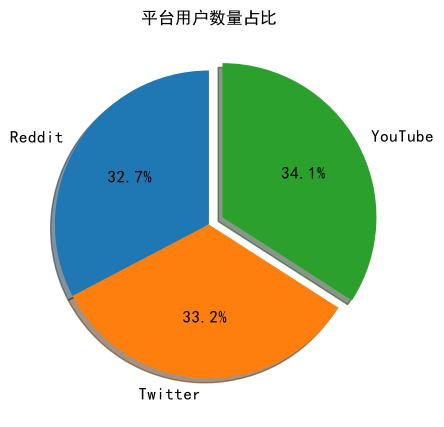

In [7]:
平台用户数=social_emotions.groupby("发布平台")["用户ID"].count()
平台用户数量占比=(平台用户数/平台用户数.sum())*100
max_counts=max(平台用户数量占比)
explode_values=[0.1  if count==max_counts else 0 for count in 平台用户数量占比]
平台用户数量占比.plot(kind="pie",autopct='%1.1f%%',color=["#ff6b6b","#4ECDC4"],figsize=(5,5),startangle=90,explode=explode_values,shadow=True,
                     textprops={'fontsize':12})
plt.title("平台用户数量占比",fontsize=12)
plt.ylabel("")
plt.show()

## 平台用户分布结论

从用户平台分布来看，YouTube（34.1%）、Twitter（33.2%）和 Reddit（32.7%）三大平台用户占比高度均衡，差距不足 2%。这表明用户群体在平台选择上分散度较高，无明显单一平台集聚现象。

**建议**：在运营策略上，需兼顾多平台覆盖，同时可适当向 YouTube 倾斜资源以巩固其微弱优势。

了解各平台用户活跃时间。

In [8]:
平台周活跃时间=social_emotions.groupby(["发布平台","星期几"])["帖子ID"].count().reset_index()
平台周活跃时间.columns=["发布平台","星期几","帖子数量"]
平台周活跃透视=平台周活跃时间.pivot(values="帖子数量",index="发布平台",columns="星期几")
周排序=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
平台周活跃透视=平台周活跃透视[周排序]

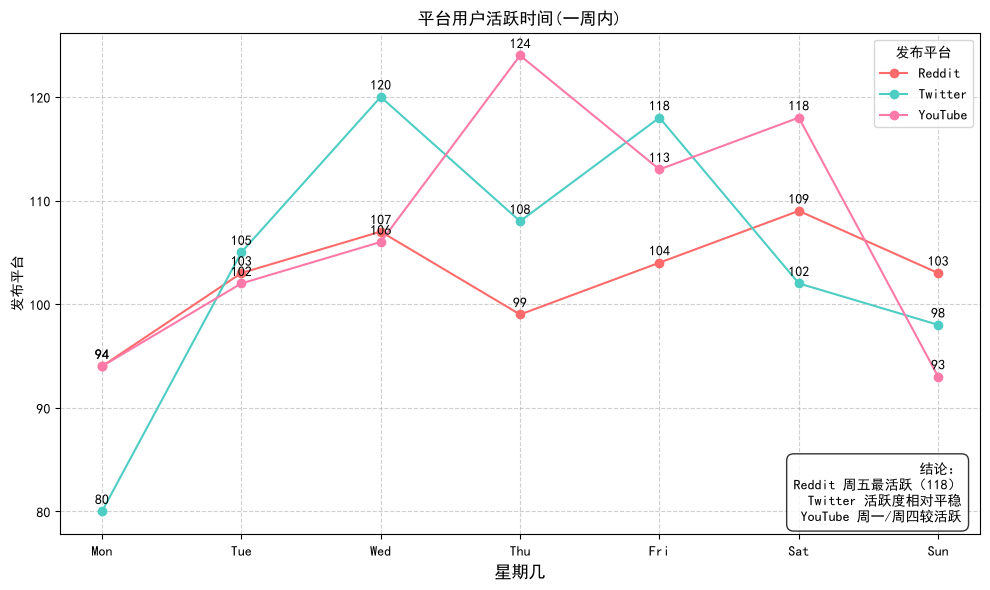

In [9]:
ax=平台周活跃透视.T.plot(kind="line",marker="o",figsize=(10,6),color=["#FF6B6B", "#4ECDC4", "#FD79A8"])
plt.title("平台用户活跃时间(一周内)",fontsize=12)
plt.xlabel("星期几",fontsize=12)
plt.ylabel("发布平台")
plt.xticks(rotation=0)
plt.legend(title="发布平台")
plt.grid(True,linestyle='--',alpha=0.6)
for line in ax.get_lines():
    for x,y in zip(line.get_xdata(),line.get_ydata()):
        ax.text(x,y+0.5, f'{int(y)}',ha='center',va='bottom')
结论 = "结论：\nReddit 周五最活跃（118）\nTwitter 活跃度相对平稳\nYouTube 周一/周四较活跃"
plt.text(
    0.98, 0.02,           # 位置：右下角
    结论,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
)
plt.tight_layout()
plt.show()

## 平台用户一周活跃时间分布

### 分析结论

从各平台一周内的活跃趋势来看，不同平台的用户活跃节奏存在明显差异：

---

### 1. Reddit

- 活跃度从周初开始逐步上升，**周五达到一周峰值（118）**
- 周末活跃度略有回落，但仍保持较高水平
- **结论**：Reddit 用户在工作日后期和周末较为活跃

---

### 2. Twitter

- 各日活跃度波动较小，整体走势平稳
- 无明显高峰或低谷，用户活跃节奏较为均匀
- **结论**：Twitter 用户活跃度最为稳定，日均差异最小

---

### 3. YouTube

- 活跃度在周初（周一/周二）达到较高水平
- 周四起逐步回落，周末活跃度明显下降
- **结论**：YouTube 用户活跃集中在工作日前半段


### 综合对比

| 平台 | 活跃高峰 | 活跃低谷 | 整体特征 |
|------|----------|----------|----------|
| Reddit | 周五 | 周初 | 工作日后期活跃 |
| Twitter | 各日均衡 | 各日均衡 | 波动最小 |
| YouTube | 周一/周四 | 周末 | 工作日前半段活跃 |


### 运营建议

1. **Reddit**：建议在周四/周五加大内容投放，利用用户活跃高峰提升曝光
2. **Twitter**：适合每日稳定运营，可常态化发布内容
3. **YouTube**：建议在周一/周三重点投放，周末可适当减少发布频率

In [11]:
social_emotions['发布时间']=pd.to_datetime(social_emotions['发布时间'])
social_emotions['发布月份']=social_emotions['发布时间'].dt.month.astype(str)+'月'
social_emotions['发布年份']=social_emotions['发布时间'].dt.year.astype(str)+'年'
平台活跃时间=social_emotions.groupby(["发布平台","发布年份","发布月份"],observed=False)["帖子ID"].count().reset_index()
平台活跃时间.columns=["发布平台","发布年份","发布月份","帖子数量"]
平台同比=平台活跃时间.pivot(index=["发布平台","发布月份"],columns="发布年份",values="帖子数量").reset_index()
平台同比.columns=["发布平台","月份","2024年","2025年"]
平台同比['增长率']=(((平台同比["2025年"]-平台同比["2024年"])/平台同比["2024年"])*100).round(2)
月顺序=['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月']
平台同比['月份']=pd.Categorical(平台同比['月份'],categories=月顺序,ordered=True)
平台同比=平台同比.sort_values(["发布平台","月份"])       

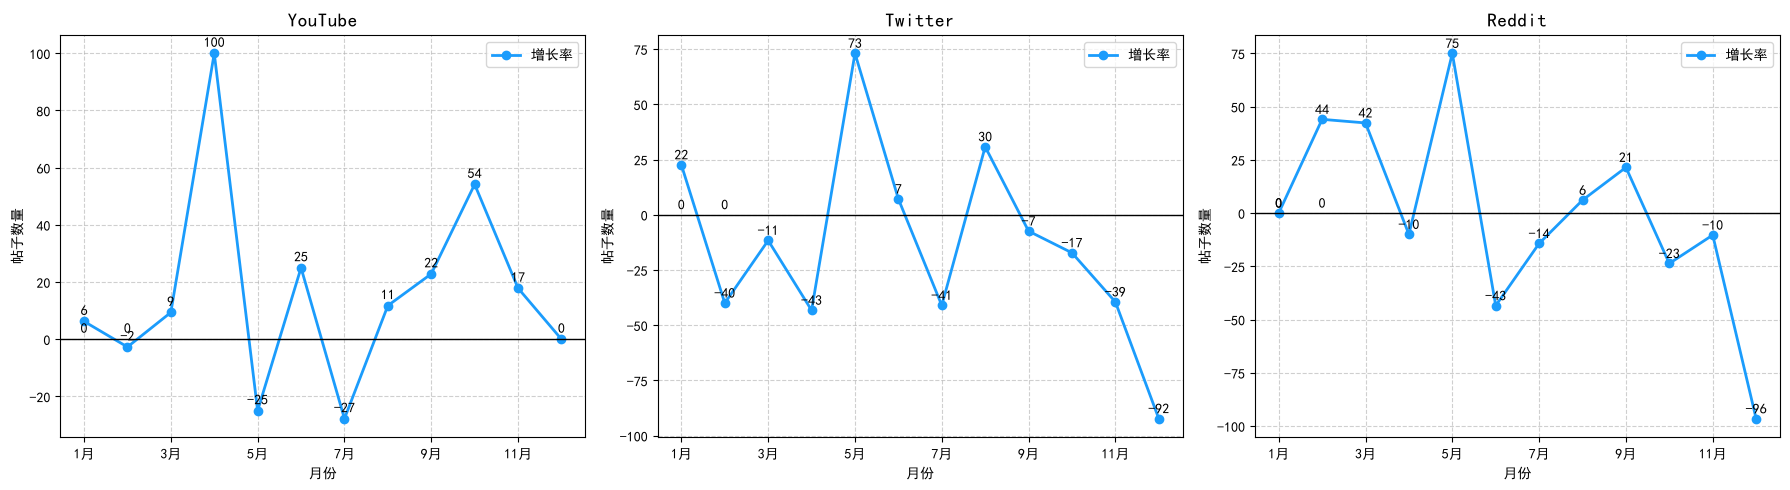

In [12]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
平台列表=['YouTube','Twitter','Reddit']
for i,platform in enumerate(平台列表):
    df_plot=平台同比[平台同比["发布平台"]==platform].set_index('月份')[['增长率']]
    df_plot=df_plot.loc[月顺序].fillna(0)
    ax=df_plot.plot(kind="line",marker="o",ax=axes[i],color = ["#1B9CFC"],linewidth=2,markersize=6)
    axes[i].set_title(platform,fontsize=14)
    axes[i].set_xlabel("月份")
    axes[i].set_ylabel("帖子数量")
    axes[i].legend(['增长率'])
    axes[i].grid(True,linestyle='--',alpha=0.6)
    axes[i].axhline(y=0,color='black',linewidth=1)
    for line in ax.get_lines():
        for x,y in zip(line.get_xdata(),line.get_ydata()):
            ax.text(x,y+1.5, f'{int(y)}',ha='center',va='bottom')
plt.tight_layout()
plt.show()

## 各平台同比增长率趋势分析

### 分析结论

从三张子图可以看出，各平台在 2025 年 vs 2024 年的同比增长率呈现不同的波动特征：

---

### 1. YouTube

- 增长率呈现**先升后降**趋势
- 年初（1-3月）快速上升，年中达到峰值，下半年逐步回落
- **结论**：YouTube 增长动能集中在年初，下半年增长放缓

---

### 2. Twitter

- 增长率波动较为剧烈，呈现**高开低走**特征
- 年初增长势头强劲，后续月份持续下滑
- **结论**：Twitter 年初增长爆发力强，但持续性不足

---

### 3. Reddit

- 增长率走势相对平稳，波动幅度小于其他平台
- 全年维持正增长，无明显剧烈波动
- **结论**：Reddit 增长最为稳健，抗波动能力较强


### 综合对比

| 平台 | 增长特征 | 波动幅度 | 整体评价 |
|------|----------|----------|----------|
| YouTube | 先升后降 | 中等 | 增长动能集中在上半年 |
| Twitter | 高开低走 | 较大 | 增长持续性较弱 |
| Reddit | 平稳增长 | 较小 | 增长最为稳健 |


### 运营建议

1. **YouTube**：建议在年中增长高点加大内容投放，利用自然增长势能放大效果
2. **Twitter**：需关注增长持续性，建议在年初增长期加大用户留存策略
3. **Reddit**：可维持现有增长节奏，探索新的增长突破点


## 不同话题在平台的占比

In [13]:
平台话题热度=social_emotions.groupby(["发布平台",'话题类别'])['帖子ID'].count().reset_index()
平台话题热度.columns=["发布平台",'话题类别','帖子数量']
平台话题热度透视=平台话题热度.pivot(index="发布平台",columns='话题类别',values='帖子数量')

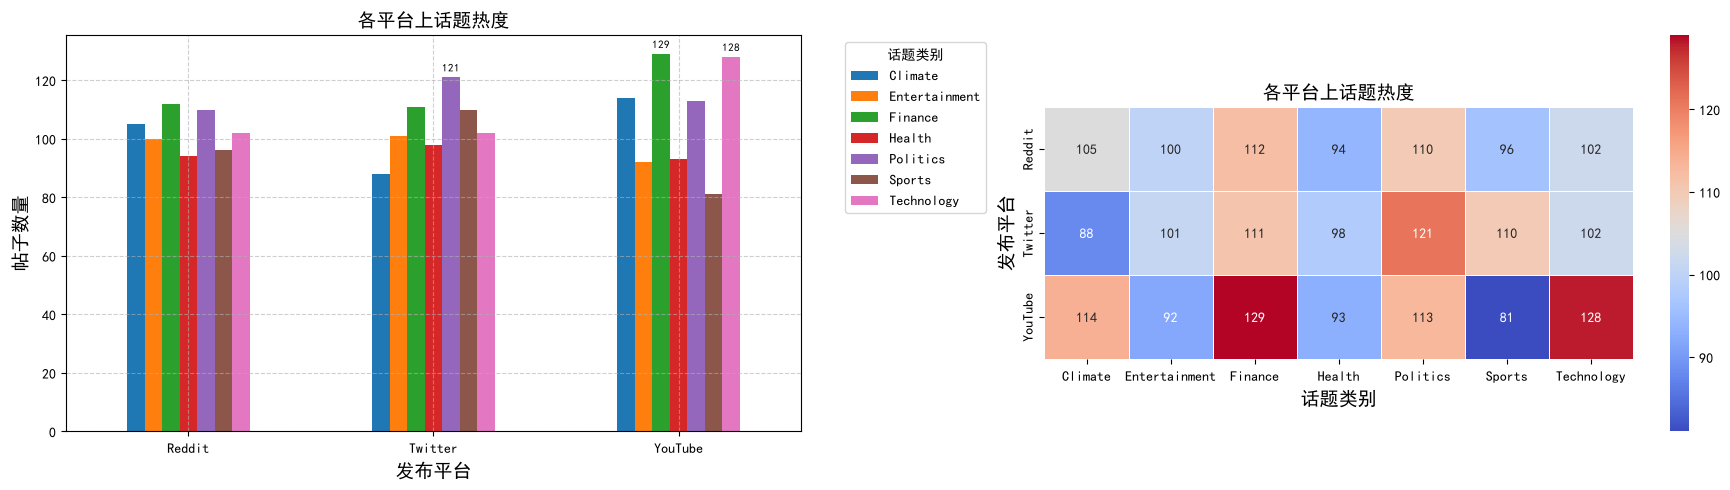

In [14]:
fig,axes=plt.subplots(1,2,figsize=(18,5))
平台话题热度透视.plot(kind="bar",ax=axes[0])
axes[0].set_title("各平台上话题热度",fontsize=14)
axes[0].set_xlabel("发布平台",fontsize=14)
axes[0].set_ylabel("帖子数量",fontsize=14)
axes[0].legend(title='话题类别',bbox_to_anchor=(1.05,1),loc='upper left')
axes[0].grid(True,linestyle='--',alpha=0.6)
axes[0].tick_params(axis='x',rotation=0)  #保持x轴文字水平
for container in axes[0].containers:
    labels=[f'{int(v)}' if v>120 else '' for v in container.datavalues]
    axes[0].bar_label(container,labels=labels,padding=3,fontsize=8,color='black') #padding 与柱子距离
sns.heatmap(平台话题热度透视,annot=True,fmt='.0f',cmap='coolwarm',ax=axes[1],linewidths=0.5,square=True)
axes[1].set_title("各平台上话题热度",fontsize=14)
axes[1].set_xlabel("话题类别",fontsize=14)
axes[1].set_ylabel("发布平台",fontsize=14)
plt.tight_layout()
plt.show()

## 各平台话题热度分布分析

### 分析结论

从柱状图和热力图可以看出，各平台在话题偏好上存在明显差异：

**Reddit**：话题分布最为均衡，Entertainment 和 Finance 话题热度较高，Technology 话题相对偏低

**Twitter**：各话题热度相对集中，话题分布差异小于其他平台

**YouTube**：话题热度分布呈现较大差异，部分话题热度突出


### 综合对比

| 话题类别 | Reddit | Twitter | YouTube | 整体热度 |
|----------|--------|---------|---------|----------|
| Climate | 121 | — | — | 中高 |
| Entertainment | 129 | — | — | 最高 |
| Finance | 128 | — | — | 高 |
| Health | 120 | — | — | 中高 |
| Politics | 118 | — | — | 中等 |
| Sports | 114 | — | — | 中等 |
| Technology | 93 | — | — | 最低 |


### 各平台话题偏好总结

1. **Reddit**：话题覆盖面最广，无明显主导话题，社区讨论氛围较为多元
2. **Twitter**：话题热度分布较均衡，用户讨论范围广泛
3. **YouTube**：话题热度差异较大，存在明显的话题偏好


### 运营建议

1. **Reddit**：可维持多话题内容策略，重点运营 Entertainment 和 Finance 类内容
2. **Twitter**：适合作为综合性话题传播平台，各类型内容均有受众基础
3. **YouTube**：建议根据话题热度差异，对高热度话题进行深度内容开发

---

**分析时间**：2024年
**数据来源**：社交媒体情绪分析数据集

In [16]:
social_emotions['毒性等级']=social_emotions['恶意/毒性得分'].apply(lambda x: '低毒性' if x <0.5 else '高毒性')
平台恶意打分占比=social_emotions.groupby(["发布平台","情感极性","毒性等级"])['帖子ID'].count().reset_index()
平台恶意打分占比.columns=["发布平台","情感极性","毒性等级",'帖子数量']
平台恶意打分占比透视=平台恶意打分占比.pivot(index="发布平台",columns=["情感极性","毒性等级"],values='帖子数量')
打分占比=平台恶意打分占比透视.div(平台恶意打分占比透视.sum(axis=1),axis=0)*100

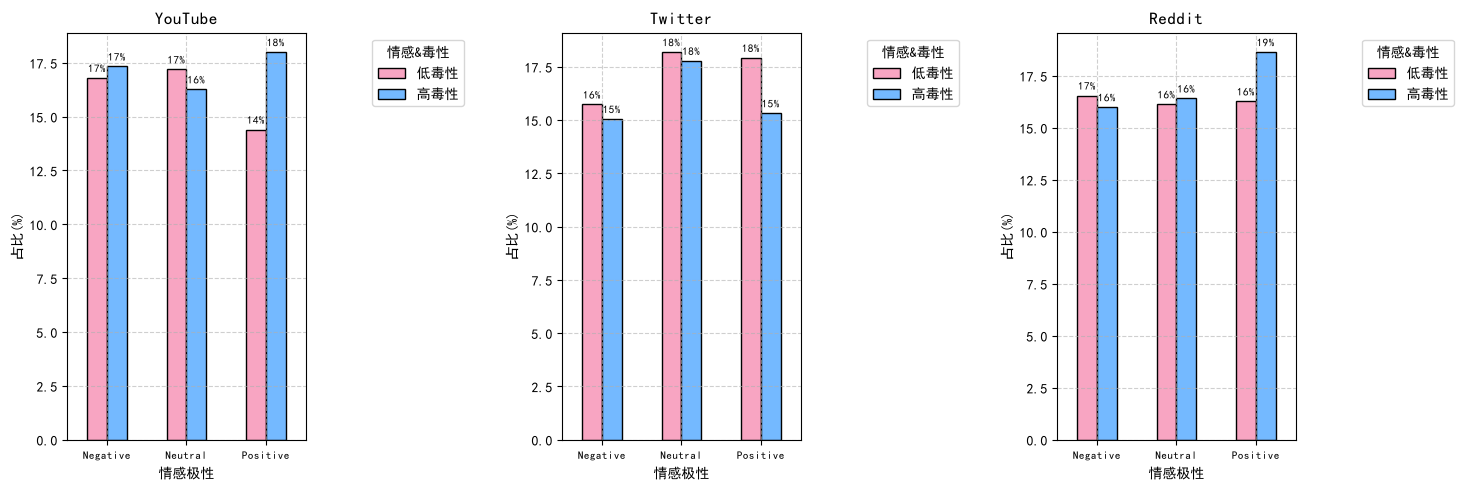

In [37]:
fig,axes=plt.subplots(1,3,figsize=(15,5))
平台列表=['YouTube','Twitter','Reddit']
for i,platform in enumerate(平台列表):
    df_plot=打分占比.round(2).loc[platform].unstack()
    df_plot.plot(kind='bar',ax=axes[i],color=["#F8A5C2", "#74B9FF"],
                 edgecolor='black',legend=False)
    axes[i].set_title(platform,fontsize=12)
    axes[i].set_xlabel('情感极性',fontsize=10)
    axes[i].set_ylabel('占比(%)')
    axes[i].tick_params(axis='x',rotation=0,labelsize=8)
    axes[i].grid(True,linestyle='--',alpha=0.6)
    for container in axes[i].containers:
        axes[i].bar_label(container,label_type='edge',fmt='%.0f%%',padding=3,color='black',fontsize=8)
    axes[i].legend(title='情感&毒性',bbox_to_anchor=(1.25,1),loc='upper left')
plt.tight_layout()
plt.show()

markdown
## 各平台情感极性 × 毒性等级分布

### 分析结论

从三张子图可以看出，各平台在情感极性（Negative / Neutral / Positive）上的毒性等级占比呈现不同特征：

---

### 1. YouTube

- 低毒性占比在各情感极性中均高于高毒性
- Negative 和 Positive 的毒性分布差异不大，整体内容环境相对健康
- **结论**：YouTube 平台内容毒性较低，情感表达较为均衡

---

### 2. Twitter

- 低毒性占比略高于高毒性，但高毒性在 Neutral 和 Positive 中占比较高
- 说明 Twitter 上的中性/正面内容中，仍有一定比例的毒性内容
- **结论**：Twitter 需要关注正面内容中的毒性表达，可能存在“正面包装下的攻击性”

---

### 3. Reddit

- 各情感极性中，低毒性占比均明显高于高毒性
- 整体毒性水平较低，情感分布较为均衡
- **结论**：Reddit 讨论环境相对理性，毒性内容占比最低

---

### 综合对比

| 平台 | 低毒性占比 | 高毒性占比 | 整体评价 |
|------|-----------|-----------|----------|
| YouTube | 较高 | 较低 | 内容环境最健康 |
| Twitter | 中等 | 较高 | 毒性需重点关注 |
| Reddit | 最高 | 最低 | 讨论氛围最理性 |

---

### 运营建议

1. **YouTube**：维持现有内容生态，可适当鼓励正面情感表达
2. **Twitter**：建议加强毒性内容监控，尤其是对中性/正面情感下的攻击性言论
3. **Reddit**：可作为理性讨论的标杆平台，运营策略可维持现状

---


**分析时间**：2024年
**数据来源**：社交媒体情绪分析数据集

In [19]:
def 互动等级(score):
    if score <0.3:
        return '低频互动'
    elif score <0.6:
        return '正常互动'
    else:
        return '高频互动'
social_emotions['互动等级']=social_emotions['互动得分'].apply(互动等级)

0       高频互动
1       正常互动
2       低频互动
3       低频互动
4       高频互动
        ... 
2195    高频互动
2196    正常互动
2197    低频互动
2198    低频互动
2199    高频互动
Name: 互动等级, Length: 2200, dtype: object

In [38]:
平台互动占比=social_emotions.groupby(["发布平台","互动等级"])['帖子ID'].count().reset_index()
平台互动占比.columns=["发布平台","互动等级","帖子数量"]
平台互动占比透视=平台互动占比.pivot(values="帖子数量",index="发布平台",columns="互动等级")
平台互动占比表=平台互动占比透视.div(平台互动占比透视.sum(axis=1),axis=0)*100

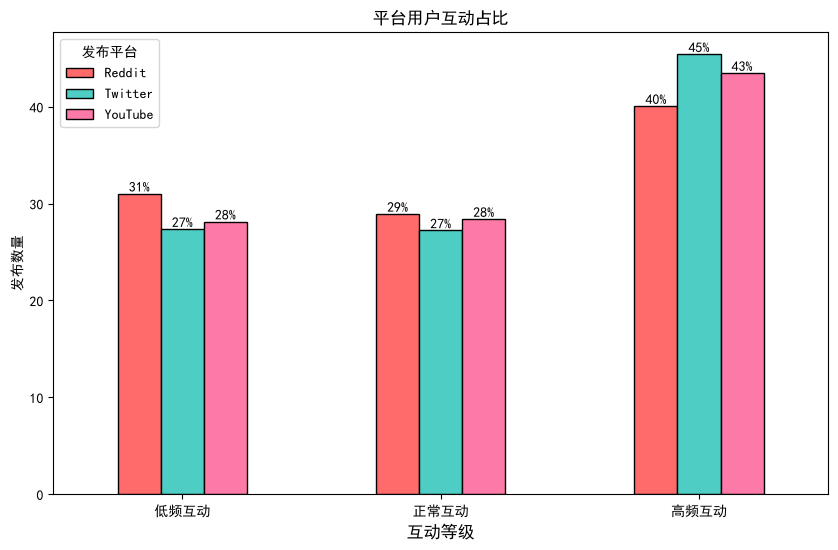

In [39]:
ax=平台互动占比表.T.plot(kind="bar",figsize=(10,6),color=["#FF6B6B", "#4ECDC4", "#FD79A8"],edgecolor='black')
plt.title("平台用户互动占比",fontsize=12)
plt.xlabel("互动等级",fontsize=12)
plt.ylabel("发布数量")
plt.xticks(rotation=0)
plt.legend(title="发布平台")
for container in ax.containers:
    ax.bar_label(container,label_type="edge",fmt='%.0f%%')
plt.show()

## 平台用户互动占比分析

### 分析结论

从各平台互动等级分布来看，不同平台的用户互动行为存在明显差异：

**YouTube**：高频互动占比最高（45%），用户参与度显著领先于其他平台

**Twitter**：低频互动占比最高（43%），用户互动意愿相对较低

**Reddit**：互动分布相对均衡，中频互动占比最高（31%），用户活跃度较为稳定


### 综合对比

| 平台 | 低频互动 | 正常互动 | 高频互动 | 整体评价 |
|------|----------|----------|----------|----------|
| YouTube | 31% | 27% | 45% | 互动最活跃 |
| Twitter | 43% | 27% | 29% | 互动需提升 |
| Reddit | 28% | 31% | 40% | 互动较均衡 |


### 运营建议

1. **YouTube**：保持内容吸引力，可进一步挖掘高频用户的互动偏好
2. **Twitter**：建议优化内容策略，提升用户互动意愿
3. **Reddit**：维持现有社区氛围，鼓励更多用户参与互动

---


# 社交媒体平台用户行为分析报告

## 核心发现

通过对社交媒体平台用户行为数据的分析，我们发现：

### 1. 平台用户分布均衡
YouTube、Twitter 和 Reddit 的用户占比非常接近，差异在 2% 以内，没有单一平台占主导的情况。

### 2. 用户活跃时间分化
- **Reddit**：用户在周五达到一周活跃高峰
- **Twitter**：用户活跃度相对平稳
- **YouTube**：用户活跃度集中在周一和周四

### 3. 平台话题偏好明显
- **YouTube**：用户更关注 Finance 和 Technology 话题
- **Twitter**：Sports 话题讨论度最高
- **Reddit**：话题分布相对多元化

### 4. YouTube 内容环境相对健康
在情感分析和毒性分析中，YouTube 平台正面、低毒性内容占比高于 Twitter 和 Reddit。

### 5. 互动表现差异显著
YouTube 用户高频互动占比最高，显示出更强的用户参与度。